In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                     05_eda_folds.ipynb                                     ║
# ║  EDA on fold composition to explain performance variance                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from prettytable import PrettyTable
from pathlib import Path
from scipy.spatial.distance import cosine

from brainvision.constants import *
from brainvision.data.io import load_all_campaigns
from brainvision.validation import build_splits_fabelo, verify_no_leakage
from brainvision.utils import build_run_name

In [2]:
# ── Load campaigns and build splits ───────────────────────────────────
campaigns  = load_all_campaigns(processed_dirs=PROCESSED_DIRS)
all_splits = build_splits_fabelo(campaigns, n_folds=5, seed=SPLIT_SEED)

Loading all campaigns from disk...
  Loaded  27 patients from ../processed/first_campaign
  Loaded  24 patients from ../processed/second_campaign
  Loaded  10 patients from ../processed/third_campaign
Loaded 61 patients across 3 campaigns

Total patients        : 34
Test set (fixed)      : 7 patients  (21% of X)  — shared across all folds
Pool for K-Fold CV    : 27 patients  (79% of X)
K-Fold                : 5 folds  (every pool patient appears in val exactly once)
Per fold → train      : ~21 patients  (64% of X)
Per fold → val        : ~5 patients  (15% of X)
Test patients         : ['012', '019', '022', '037', '038', '042', '053']

  Fold 1: train=34 images (21 pts)  val=12 images ( 6 pts)  test=15 images (7 pts, fixed)
  Fold 2: train=35 images (21 pts)  val=11 images ( 6 pts)  test=15 images (7 pts, fixed)
  Fold 3: train=39 images (22 pts)  val= 7 images ( 5 pts)  test=15 images (7 pts, fixed)
  Fold 4: train=39 images (22 pts)  val= 7 images ( 5 pts)  test=15 images (7 pts, fixe

In [3]:
# ── Per-fold class distribution analysis ──────────────────────────────
def analyse_class_distribution(patients: list[dict],
                                split_name: str) -> dict:
    """
    Compute per-class pixel counts and ratios for a set of patients.
    """
    counts = {c: 0 for c in range(N_CLASSES)}

    for p in patients:
        label_map = p['labels']
        for c in range(N_CLASSES):
            counts[c] += (label_map == (c + 1)).sum()

    total    = sum(counts.values())
    tt_count = counts[1]   # TT = class index 1
    nt_count = counts[0]   # NT = class index 0

    return {
        'split'     : split_name,
        'total'     : total,
        'counts'    : counts,
        'pcts'      : {c: counts[c] / total * 100 if total > 0 else 0
                       for c in range(N_CLASSES)},
        'nt_tt_ratio': nt_count / tt_count if tt_count > 0 else float('inf'),
        'has_tt'    : tt_count > 0,
        'n_images'  : len(patients),
        'n_patients': len(set(p['id'].split('-')[0] for p in patients)),
    }


def analyse_campaign_composition(patients: list[dict]) -> dict:
    """Count how many images come from each campaign."""
    comp = {1: 0, 2: 0, 3: 0}
    for p in patients:
        pid = p['id']
        # Campaign 1: patient IDs from first_campaign folder
        for c, plist in campaigns.items():
            if any(cp['id'] == pid for cp in plist):
                comp[c] += 1
                break
    return comp


def compute_spectral_separability(patients: list[dict]) -> dict:
    """
    Compute spectral separability between NT and TT using:
      - SAM (Spectral Angle Mapper) between mean spectra
      - Bhattacharyya distance between spectral distributions
      - Overlap ratio of NT and TT spectral ranges
    """
    nt_spectra = []
    tt_spectra = []

    for p in patients:
        cube      = p['processed']   # (H, W, 128)
        label_map = p['labels']      # (H, W)
        H, W, C   = cube.shape
        flat_cube = cube.reshape(-1, C)
        flat_labels = label_map.reshape(-1)

        nt_mask = flat_labels == 1   # NT = label 1
        tt_mask = flat_labels == 2   # TT = label 2

        if nt_mask.sum() > 0:
            nt_spectra.append(flat_cube[nt_mask])
        if tt_mask.sum() > 0:
            tt_spectra.append(flat_cube[tt_mask])

    if not nt_spectra or not tt_spectra:
        return {'sam': float('nan'), 'separability': 'unknown'}

    nt_all   = np.vstack(nt_spectra)
    tt_all   = np.vstack(tt_spectra)

    nt_mean  = nt_all.mean(axis=0)
    tt_mean  = tt_all.mean(axis=0)
    nt_std   = nt_all.std(axis=0)
    tt_std   = tt_all.std(axis=0)

    # SAM — angle between mean spectra (radians)
    # smaller = more similar = harder to classify
    sam      = np.arccos(np.clip(
        np.dot(nt_mean, tt_mean) /
        (np.linalg.norm(nt_mean) * np.linalg.norm(tt_mean) + 1e-8),
        -1, 1
    ))

    # Mean spectral distance (L2)
    l2_dist  = np.linalg.norm(nt_mean - tt_mean)

    # Intra-class variance (how consistent is TT within this fold?)
    tt_intra_var = tt_std.mean()
    nt_intra_var = nt_std.mean()

    return {
        'sam_rad'       : float(sam),
        'sam_deg'       : float(np.degrees(sam)),
        'l2_dist'       : float(l2_dist),
        'tt_intra_var'  : float(tt_intra_var),
        'nt_intra_var'  : float(nt_intra_var),
        'nt_mean'       : nt_mean,
        'tt_mean'       : tt_mean,
        'nt_std'        : nt_std,
        'tt_std'        : tt_std,
        'n_nt_pixels'   : len(nt_all),
        'n_tt_pixels'   : len(tt_all),
    }


In [4]:
# ── Run analysis on all folds ────────────────────────────────────────
fold_analyses = []

for split in all_splits:
    fold = split['fold']
    print(f"\nAnalysing fold {fold}...")

    val_dist   = analyse_class_distribution(split['val'],   f"fold{fold}_val")
    test_dist  = analyse_class_distribution(split['test'],  f"fold{fold}_test")
    train_dist = analyse_class_distribution(split['train'], f"fold{fold}_train")

    val_camp   = analyse_campaign_composition(split['val'])
    test_camp  = analyse_campaign_composition(split['test'])
    train_camp = analyse_campaign_composition(split['train'])

    val_sep    = compute_spectral_separability(split['val'])
    test_sep   = compute_spectral_separability(split['test'])

    fold_analyses.append({
        'fold'      : fold,
        'train_dist': train_dist,
        'val_dist'  : val_dist,
        'test_dist' : test_dist,
        'val_camp'  : val_camp,
        'test_camp' : test_camp,
        'train_camp': train_camp,
        'val_sep'   : val_sep,
        'test_sep'  : test_sep,
    })

    print(f"  Train: {train_dist['n_images']} images  "
          f"TT={train_dist['pcts'][1]:.1f}%  "
          f"NT:TT ratio={train_dist['nt_tt_ratio']:.1f}")
    print(f"  Val  : {val_dist['n_images']} images  "
          f"TT={val_dist['pcts'][1]:.1f}%  "
          f"NT:TT ratio={val_dist['nt_tt_ratio']:.1f}  "
          f"SAM={np.degrees(val_sep['sam_rad']):.2f}°")
    print(f"  Test : {test_dist['n_images']} images  "
          f"TT={test_dist['pcts'][1]:.1f}%  "
          f"NT:TT ratio={test_dist['nt_tt_ratio']:.1f}  "
          f"SAM={np.degrees(test_sep['sam_rad']):.2f}°")




Analysing fold 1...
  Train: 34 images  TT=3.7%  NT:TT ratio=9.2
  Val  : 12 images  TT=3.2%  NT:TT ratio=4.5  SAM=6.88°
  Test : 15 images  TT=5.5%  NT:TT ratio=8.1  SAM=3.97°

Analysing fold 2...
  Train: 35 images  TT=3.3%  NT:TT ratio=9.8
  Val  : 11 images  TT=4.6%  NT:TT ratio=5.3  SAM=2.97°
  Test : 15 images  TT=5.5%  NT:TT ratio=8.1  SAM=3.97°

Analysing fold 3...
  Train: 39 images  TT=3.7%  NT:TT ratio=7.8
  Val  : 7 images  TT=2.9%  NT:TT ratio=13.9  SAM=3.79°
  Test : 15 images  TT=5.5%  NT:TT ratio=8.1  SAM=3.97°

Analysing fold 4...
  Train: 39 images  TT=3.7%  NT:TT ratio=9.3
  Val  : 7 images  TT=3.5%  NT:TT ratio=4.4  SAM=3.42°
  Test : 15 images  TT=5.5%  NT:TT ratio=8.1  SAM=3.97°

Analysing fold 5...
  Train: 37 images  TT=3.7%  NT:TT ratio=5.9
  Val  : 9 images  TT=3.4%  NT:TT ratio=17.5  SAM=5.42°
  Test : 15 images  TT=5.5%  NT:TT ratio=8.1  SAM=3.97°


In [5]:

# ── Summary table ─────────────────────────────────────────────────────
def print_fold_complexity_table(fold_analyses: list[dict]):
    """Print a summary table correlating fold complexity with performance."""
    table = PrettyTable()
    table.field_names = [
        "Fold",
        "Val TT%", "Val NT:TT", "Val SAM°", "Val TT Var",
        "Test TT%", "Test NT:TT", "Test SAM°",
        "C1 val", "C2 val", "C3 val",
    ]
    for col in table.field_names[1:]:
        table.align[col] = 'r'

    for fa in fold_analyses:
        vd  = fa['val_dist']
        td  = fa['test_dist']
        vs  = fa['val_sep']
        ts  = fa['test_sep']
        vc  = fa['val_camp']

        table.add_row([
            f"Fold {fa['fold']}",
            f"{vd['pcts'][1]:.1f}%",
            f"{vd['nt_tt_ratio']:.1f}",
            f"{vs['sam_deg']:.2f}",
            f"{vs['tt_intra_var']:.4f}",
            f"{td['pcts'][1]:.1f}%",
            f"{td['nt_tt_ratio']:.1f}",
            f"{ts['sam_deg']:.2f}",
            str(vc[1]),
            str(vc[2]),
            str(vc[3]),
        ])

    print(f"\n{'═'*100}")
    print(f"  FOLD COMPLEXITY ANALYSIS")
    print(f"  SAM° = Spectral Angle between mean NT and TT spectra "
          f"(smaller = harder to distinguish)")
    print(f"  TT Var = intra-class spectral variance of TT pixels")
    print(f"{'═'*100}")
    print(table)


print_fold_complexity_table(fold_analyses)


════════════════════════════════════════════════════════════════════════════════════════════════════
  FOLD COMPLEXITY ANALYSIS
  SAM° = Spectral Angle between mean NT and TT spectra (smaller = harder to distinguish)
  TT Var = intra-class spectral variance of TT pixels
════════════════════════════════════════════════════════════════════════════════════════════════════
+--------+---------+-----------+----------+------------+----------+------------+-----------+--------+--------+--------+
|  Fold  | Val TT% | Val NT:TT | Val SAM° | Val TT Var | Test TT% | Test NT:TT | Test SAM° | C1 val | C2 val | C3 val |
+--------+---------+-----------+----------+------------+----------+------------+-----------+--------+--------+--------+
| Fold 1 |    3.2% |       4.5 |     6.88 |     0.0663 |     5.5% |        8.1 |      3.97 |      8 |      3 |      1 |
| Fold 2 |    4.6% |       5.3 |     2.97 |     0.0835 |     5.5% |        8.1 |      3.97 |      5 |      4 |      2 |
| Fold 3 |    2.9% |      1

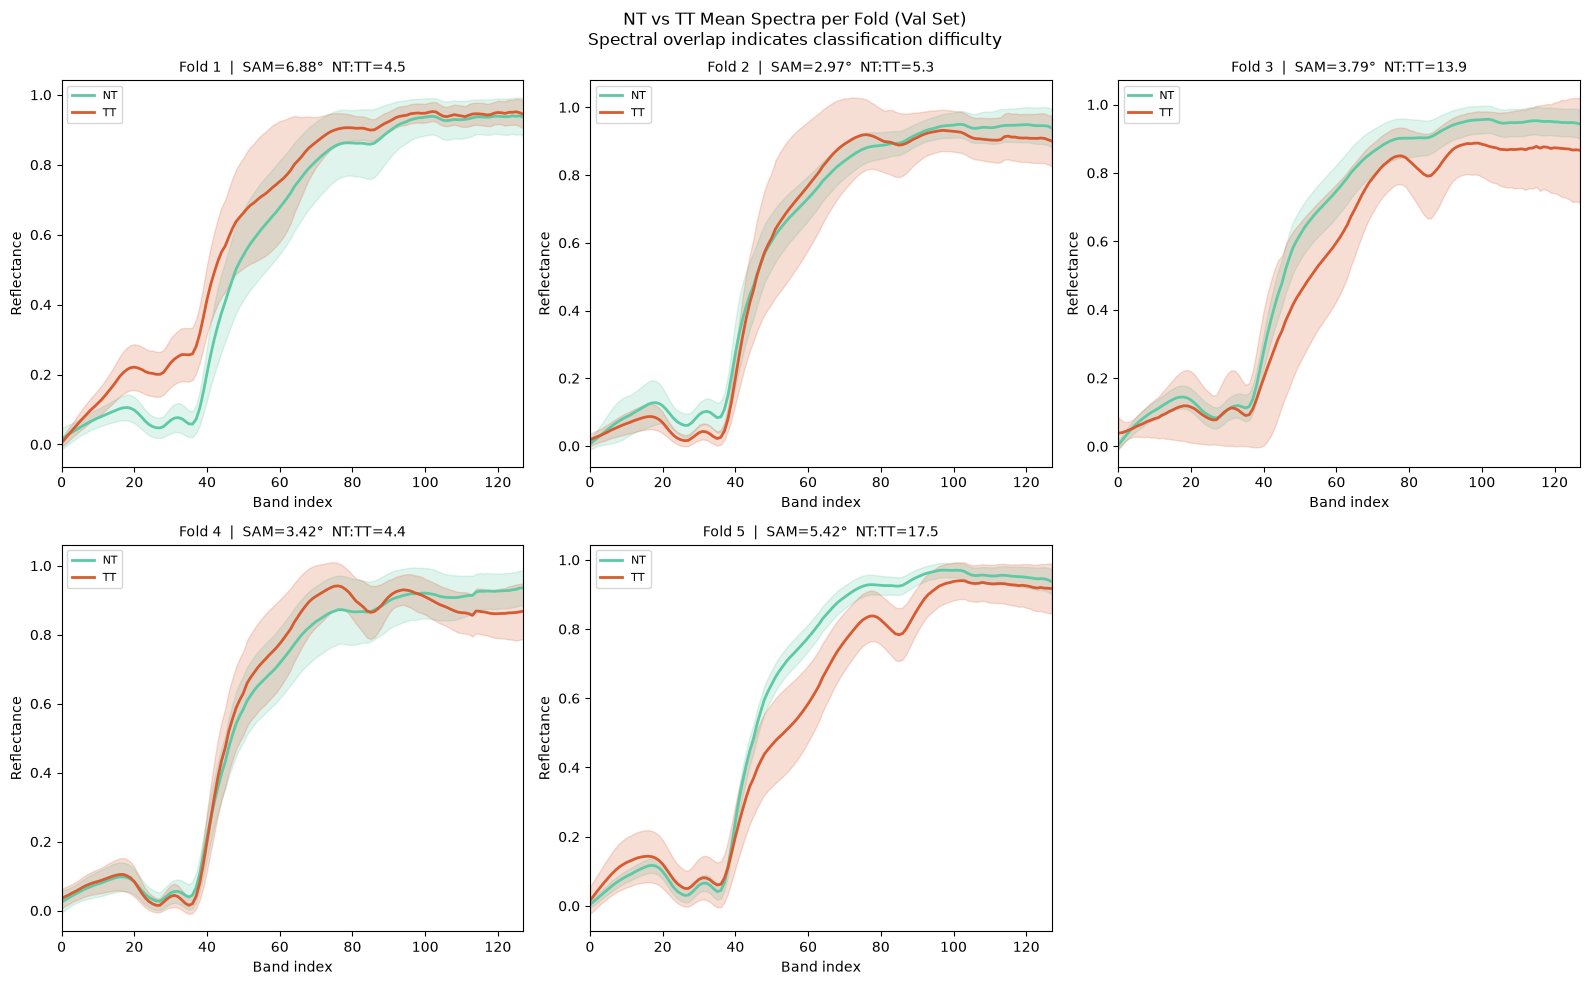

Saved → ../results/fold_nt_tt_spectra.png


In [6]:

# ── Visual — mean spectra per fold ────────────────────────────────────
def plot_nt_tt_spectra_per_fold(fold_analyses: list[dict]):
    """
    Plot mean NT and TT spectra for val set of each fold.
    Highlights spectral overlap — larger overlap = harder fold.
    """
    n_folds = len(fold_analyses)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(
        "NT vs TT Mean Spectra per Fold (Val Set)\n"
        "Spectral overlap indicates classification difficulty",
        fontsize=12
    )
    axes = axes.flatten()
    bands = np.arange(N_DECIMATED_BANDS)

    for i, fa in enumerate(fold_analyses):
        ax  = axes[i]
        vs  = fa['val_sep']
        fold = fa['fold']

        if np.isnan(vs['sam_rad']):
            ax.text(0.5, 0.5, 'No TT pixels in val set',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"Fold {fold}")
            continue

        nt_mean = vs['nt_mean']
        tt_mean = vs['tt_mean']
        nt_std  = vs['nt_std']
        tt_std  = vs['tt_std']

        ax.plot(bands, nt_mean, color='#5DCAA5', linewidth=2, label='NT')
        ax.fill_between(bands, nt_mean - nt_std, nt_mean + nt_std,
                         alpha=0.2, color='#5DCAA5')

        ax.plot(bands, tt_mean, color='#D85A30', linewidth=2, label='TT')
        ax.fill_between(bands, tt_mean - tt_std, tt_mean + tt_std,
                         alpha=0.2, color='#D85A30')

        ax.set_title(
            f"Fold {fold}  |  SAM={vs['sam_deg']:.2f}°  "
            f"NT:TT={fa['val_dist']['nt_tt_ratio']:.1f}",
            fontsize=10
        )
        ax.set_xlabel("Band index")
        ax.set_ylabel("Reflectance")
        ax.legend(fontsize=8)
        ax.set_xlim(0, N_DECIMATED_BANDS - 1)

    # Hide unused subplot
    axes[-1].axis('off')

    plt.tight_layout()
    out = Path(RESULTS_DIR) / "fold_nt_tt_spectra.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")


plot_nt_tt_spectra_per_fold(fold_analyses)


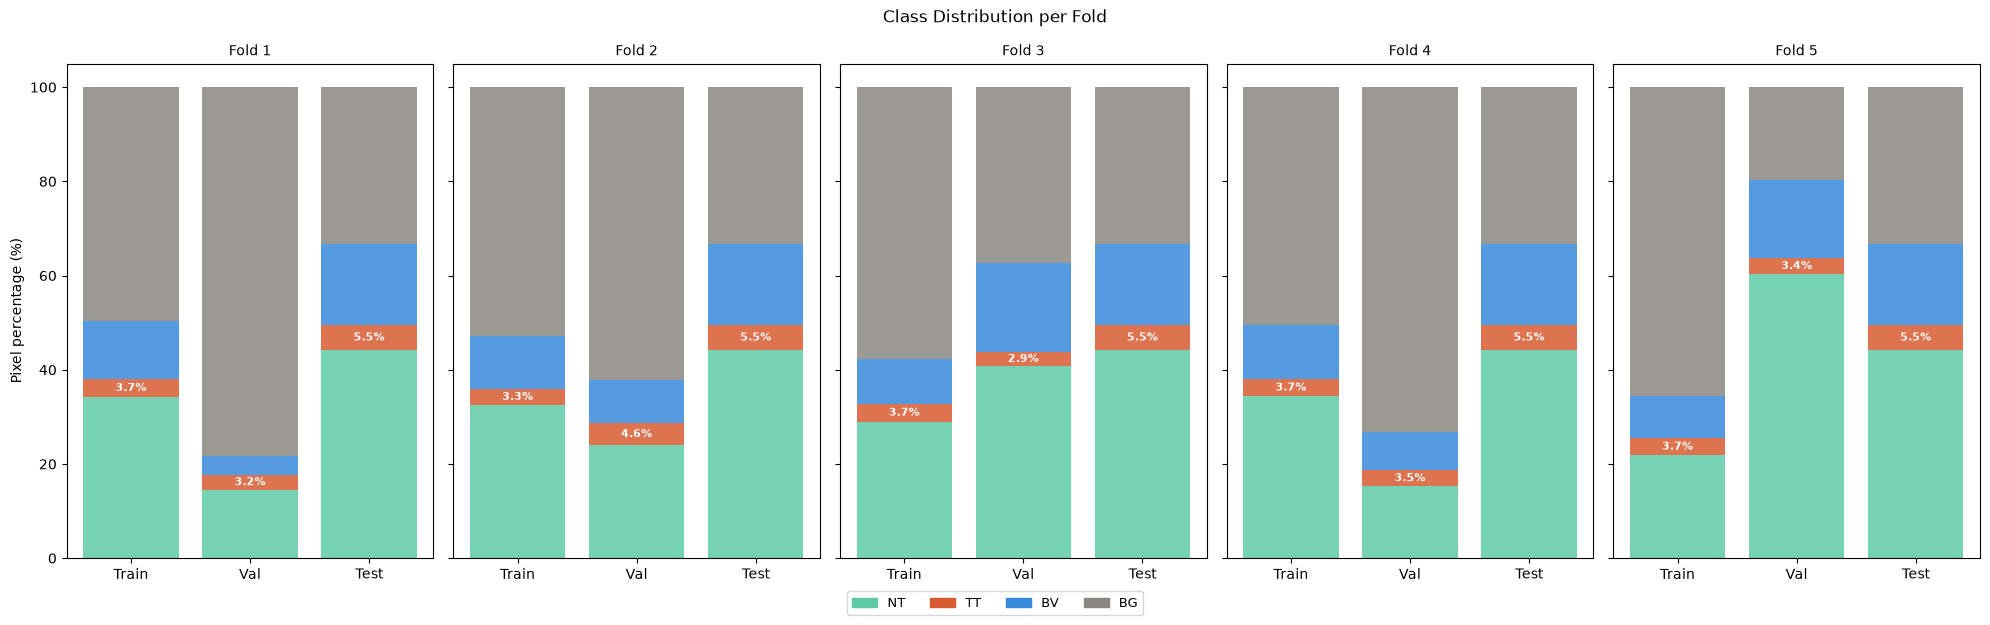

Saved → ../results/fold_class_distribution.png


In [7]:
# ── Visual — class distribution per fold ──────────────────────────────
def plot_class_distribution_per_fold(fold_analyses: list[dict]):
    """
    Stacked bar chart showing class pixel percentages per fold
    for train, val and test sets side by side.
    """
    n_folds = len(fold_analyses)
    fig, axes = plt.subplots(1, n_folds, figsize=(4 * n_folds, 6),
                              sharey=True)
    fig.suptitle("Class Distribution per Fold", fontsize=12)

    colors = ['#5DCAA5', '#D85A30', '#378ADD', '#888780']
    labels = [CLASS_NAMES_SHORT[i+1] for i in range(N_CLASSES)]

    for i, (fa, ax) in enumerate(zip(fold_analyses, axes)):
        splits_data = [
            ('Train', fa['train_dist']['pcts']),
            ('Val',   fa['val_dist']['pcts']),
            ('Test',  fa['test_dist']['pcts']),
        ]

        x      = np.arange(len(splits_data))
        bottom = np.zeros(len(splits_data))

        for c in range(N_CLASSES):
            vals = [d[1][c] for d in splits_data]
            bars = ax.bar(x, vals, bottom=bottom,
                          color=colors[c], label=labels[c],
                          alpha=0.85)

            # Label TT bars specifically
            if c == 1:   # TT
                for bar, val in zip(bars, vals):
                    if val > 1:
                        ax.text(bar.get_x() + bar.get_width()/2,
                                bar.get_y() + bar.get_height()/2,
                                f'{val:.1f}%',
                                ha='center', va='center',
                                fontsize=8, fontweight='bold',
                                color='white')
            bottom += np.array(vals)

        ax.set_title(f"Fold {fa['fold']}", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels([d[0] for d in splits_data])
        ax.set_ylim(0, 105)
        if i == 0:
            ax.set_ylabel("Pixel percentage (%)")

    handles = [plt.Rectangle((0,0),1,1, color=colors[c])
               for c in range(N_CLASSES)]
    fig.legend(handles, labels, loc='lower center',
               ncol=N_CLASSES, fontsize=9,
               bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    out = Path(RESULTS_DIR) / "fold_class_distribution.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")


plot_class_distribution_per_fold(fold_analyses)


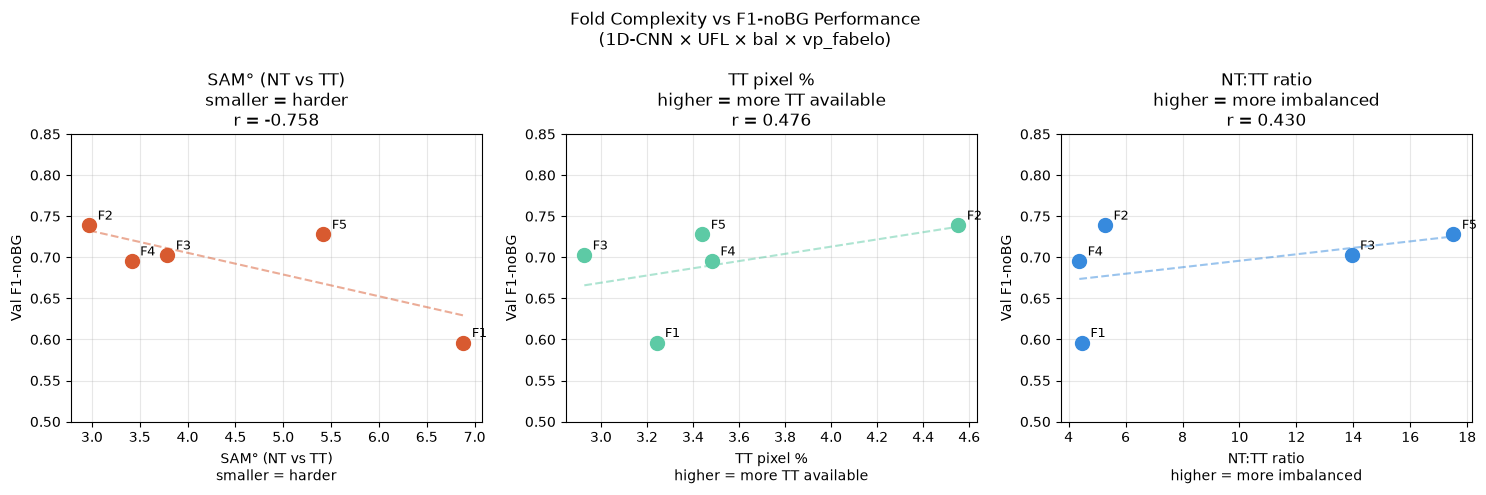

Saved → ../results/fold_complexity_vs_f1.png


In [8]:
# ── Correlation — complexity vs performance ───────────────────────────
def plot_complexity_vs_performance(fold_analyses: list[dict],
                                    known_f1: dict):
    """
    Scatter plots correlating fold complexity metrics with F1-noBG.

    Args:
        known_f1 : dict mapping fold number to achieved F1-noBG
                   e.g. {1: 0.5962, 2: 0.7391, ...}
    """
    folds    = sorted(known_f1.keys())
    f1_vals  = [known_f1[f] for f in folds]
    sam_vals = [fold_analyses[f-1]['val_sep']['sam_deg'] for f in folds]
    tt_pcts  = [fold_analyses[f-1]['val_dist']['pcts'][1] for f in folds]
    nt_tt    = [fold_analyses[f-1]['val_dist']['nt_tt_ratio'] for f in folds]
    tt_var   = [fold_analyses[f-1]['val_sep']['tt_intra_var'] for f in folds]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Fold Complexity vs F1-noBG Performance\n"
                 "(1D-CNN × UFL × bal × vp_fabelo)", fontsize=12)

    def _scatter(ax, x_vals, x_label, color):
        ax.scatter(x_vals, f1_vals, color=color, s=100, zorder=5)
        for j, fold in enumerate(folds):
            ax.annotate(f"F{fold}",
                        (x_vals[j], f1_vals[j]),
                        textcoords="offset points",
                        xytext=(6, 4), fontsize=9)
        # Trend line
        z   = np.polyfit(x_vals, f1_vals, 1)
        p   = np.poly1d(z)
        xr  = np.linspace(min(x_vals), max(x_vals), 100)
        ax.plot(xr, p(xr), '--', color=color, alpha=0.5)
        ax.set_xlabel(x_label)
        ax.set_ylabel("Val F1-noBG")
        ax.set_ylim(0.5, 0.85)
        ax.grid(alpha=0.3)

        # Correlation coefficient
        corr = np.corrcoef(x_vals, f1_vals)[0, 1]
        ax.set_title(f"{x_label}\nr = {corr:.3f}")

    _scatter(axes[0], sam_vals,
             "SAM° (NT vs TT)\nsmaller = harder", '#D85A30')
    _scatter(axes[1], tt_pcts,
             "TT pixel %\nhigher = more TT available", '#5DCAA5')
    _scatter(axes[2], nt_tt,
             "NT:TT ratio\nhigher = more imbalanced", '#378ADD')

    plt.tight_layout()
    out = Path(RESULTS_DIR) / "fold_complexity_vs_f1.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")


# Plug in your known F1 results per fold (update as you get more results)
known_f1_1dcnn_ufl = {
    1: 0.5962,
    2: 0.7391,
    3: 0.7027,
    4: 0.6955,
    5: 0.7279,
}

plot_complexity_vs_performance(fold_analyses, known_f1_1dcnn_ufl)